In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import os
import sys
from path import PathFinder
sns.set(style="whitegrid")


In [19]:
PATHS = PathFinder()
DIR_OUT = PATHS["DIR_SRC"] / "out" 
df_s1 = pd.read_csv(DIR_OUT / "study1.csv")
df_s2 = pd.read_csv(DIR_OUT / "study2.csv")
df_time = pd.read_csv(DIR_OUT / "train_time.csv")
df_ram = pd.read_csv(DIR_OUT / "train_mem.csv")
df_infer = pd.read_csv(DIR_OUT / "infer.csv", header=None)

Successfully loaded /home/niche/projects/COLO/.env
Available project environments: 
    DIR_SRC=/home/niche/projects/COLO
    DIR_DATA=/home/niche/data/cow-colo
    LIB_PYNICHE=/home/niche/projects/pyniche
    DIR_TMP=/


In [20]:
DICT_PARAMS = dict({
    "rtdetr-l": 45,
    "rtdetr-x": 86,
    "yolo12n": 2.6,
    "yolo12m": 20.2,
    "yolo12x": 59.1,
    "yolo11n": 2.6,
    "yolo11m": 20.1,
    "yolo11x": 56.9,
})
def add_params(df):
    df.loc[:, "params"] = df["model"].map(DICT_PARAMS)
    return df

def add_family(df):
    df.loc[:, ["family"]] = "DETR"
    df.loc[df["model"].str.contains("yolo12"), "family"] = "YOLOv12"
    df.loc[df["model"].str.contains("yolo11"), "family"] = "YOLOv11"
    return df

def add_size(df):
    df.loc[:, ["size"]] = "small"
    df.loc[df["model"].str.contains("yolo11x"), "size"] = "large"
    df.loc[df["model"].str.contains("yolo12x"), "size"] = "large"
    df.loc[df["model"].str.contains("rtdetr-x"), "size"] = "large"
    return df

def add_info(df):
    df = add_family(df)
    df = add_size(df)
    df = add_params(df)
    return df
df_infer.columns = ["model", "fps", "gpu"]
df_infer = add_info(df_infer)
df_infer

,model,fps,gpu,family,size,params
0,yolo11x,157.95,L40S,YOLOv11,large,56.9
1,yolo11x,128.22,L40S,YOLOv11,large,56.9
2,yolo11x,128.18,L40S,YOLOv11,large,56.9
3,yolo11x,128.13,L40S,YOLOv11,large,56.9
4,yolo11x,128.12,L40S,YOLOv11,large,56.9
...,...,...,...,...,...,...
328,rtdetr-l,116.17,3080ti,DETR,small,45.0
329,rtdetr-l,115.85,3080ti,DETR,small,45.0
330,rtdetr-l,116.17,3080ti,DETR,small,45.0
331,rtdetr-l,115.89,3080ti,DETR,small,45.0


[None,
 [Text(0, 32, '32'),
  Text(0, 64, '64'),
  Text(0, 128, '128'),
  Text(0, 256, '256'),
  Text(0, 512, '512'),
  Text(0, 1024, '1024'),
  Text(0, 2048, '2048')],
 Text(0, 0.5, 'Frames per Seconds (log)')]

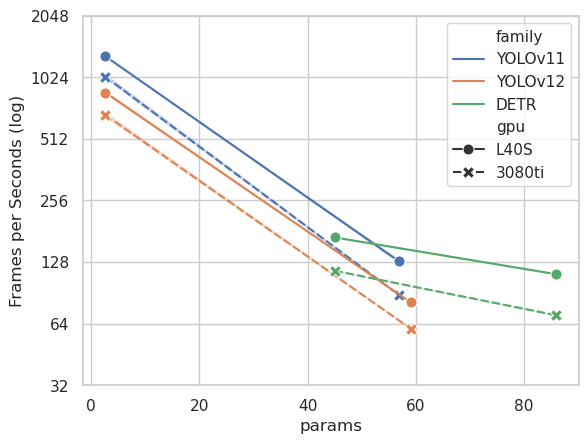

In [22]:
sns.set(style="whitegrid")

g = sns.lineplot(data=df_infer, x="params", y="fps",
             hue="family", style="gpu",
             hue_order=["YOLOv11", "YOLOv12", "DETR"],
             markers=True, markersize=8,)
g.set(
    yscale="log",
    yticks=[2**i for i in range(5, 12)],
    yticklabels=[2**i for i in range(5, 12)],
    ylabel="Frames per Seconds (log)")

In [ ]:
df_s1.loc[:, ["data", "model", "n", "map5095"]].\
    groupby(["data", "model", "n"]).\
        aggregate({"map5095": ["mean", "std", "median"]}).reset_index().\
            to_csv(DIR_OUT / "study1_pivot.csv", index=False)

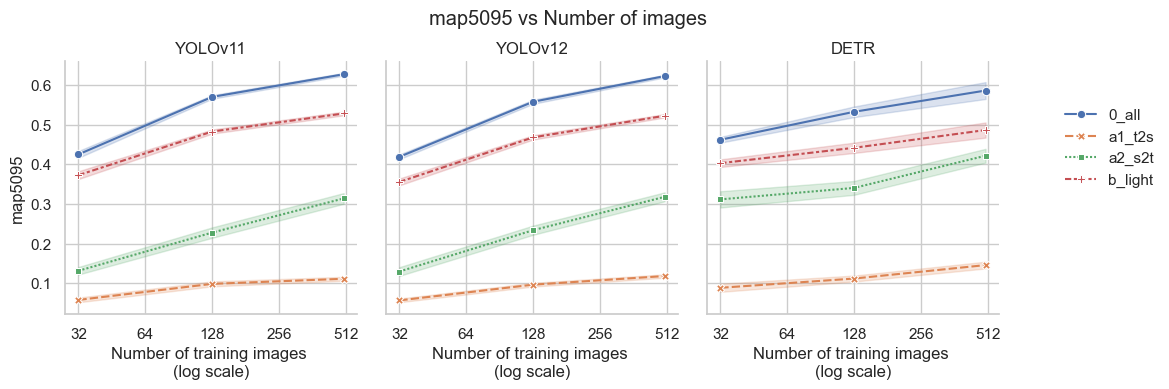

In [10]:
config_s1 = ["0_all", "a1_t2s", "a2_s2t", "b_light"]
sns.set(style="whitegrid")

def plot_s1_overview(df, metric):
    g = sns.FacetGrid(df, 
        col="family", col_order=["YOLOv11", "YOLOv12", "DETR"],
        sharey="row",margin_titles=True, 
        # height=6, aspect=1.2
        )
    g.map_dataframe(sns.lineplot, 
        x="n", y=metric, hue="data", style="data",
        err_style="band", errorbar=("se", 2),
        markers=True,)
    g.set(
        xscale="log",
        xticks=[2**i for i in range(5, 10)],
        xticklabels=[2**i for i in range(5, 10)],
        xlabel="Number of training images \n(log scale)",)
    # set bbox to relative x, y to axis
    g.add_legend(bbox_to_anchor=(1, .5), loc='lower right')
    g.set_titles(col_template="{col_name}")
    g.figure.set_size_inches(12, 4)
    # set 10% space above the plot, 20% space between rows, and 10% space between columns
    g.figure.subplots_adjust(top=0.85, hspace=0.2, wspace=0.1)
    g.fig.suptitle(f"{metric} vs Number of images")
    return g

g = plot_s1_overview(df_s1, "map5095")
# save
g.savefig(PATHS["DIR_SRC"]/"ms"/"r1"/"src"/"fig_s1_overview.png", dpi=300)

In [41]:
import scipy.stats as stats
config_s1 = ["0_all", "a1_t2s", "a2_s2t", "b_light"]
ls_family = ["YOLOv11", "YOLOv12", "DETR"]
ls_n = [32, 128, 500]
for c in config_s1:
    for f in ls_family:
        for n in ls_n:
            df_sub = df_s1.query(f"data == '{c}' and family == '{f}' and n == {n}")
            df_small = df_sub.query("size == 'small'")
            df_large = df_sub.query("size == 'large'")
            # run t-test on map5095
            t_stat, p_val = stats.ttest_ind(df_small["map5095"], df_large["map5095"])
            print(f"Config: {c}, Family: {f}, n: {n}, t-stat: {t_stat:.2f}, p-val: {p_val:.2e}")


Config: 0_all, Family: YOLOv11, n: 32, t-stat: 5.56, p-val: 1.95e-06
Config: 0_all, Family: YOLOv11, n: 128, t-stat: -1.80, p-val: 7.93e-02
Config: 0_all, Family: YOLOv11, n: 500, t-stat: -6.83, p-val: 4.16e-08
Config: 0_all, Family: YOLOv12, n: 32, t-stat: 2.65, p-val: 1.11e-02
Config: 0_all, Family: YOLOv12, n: 128, t-stat: -2.61, p-val: 1.24e-02
Config: 0_all, Family: YOLOv12, n: 500, t-stat: -9.21, p-val: 7.82e-12
Config: 0_all, Family: DETR, n: 32, t-stat: 2.82, p-val: 7.57e-03
Config: 0_all, Family: DETR, n: 128, t-stat: 1.38, p-val: 1.74e-01
Config: 0_all, Family: DETR, n: 500, t-stat: 2.61, p-val: 1.30e-02
Config: a1_t2s, Family: YOLOv11, n: 32, t-stat: 2.31, p-val: 2.61e-02
Config: a1_t2s, Family: YOLOv11, n: 128, t-stat: 1.56, p-val: 1.27e-01
Config: a1_t2s, Family: YOLOv11, n: 500, t-stat: 2.77, p-val: 8.67e-03
Config: a1_t2s, Family: YOLOv12, n: 32, t-stat: -0.37, p-val: 7.12e-01
Config: a1_t2s, Family: YOLOv12, n: 128, t-stat: -2.05, p-val: 4.68e-02
Config: a1_t2s, Family:

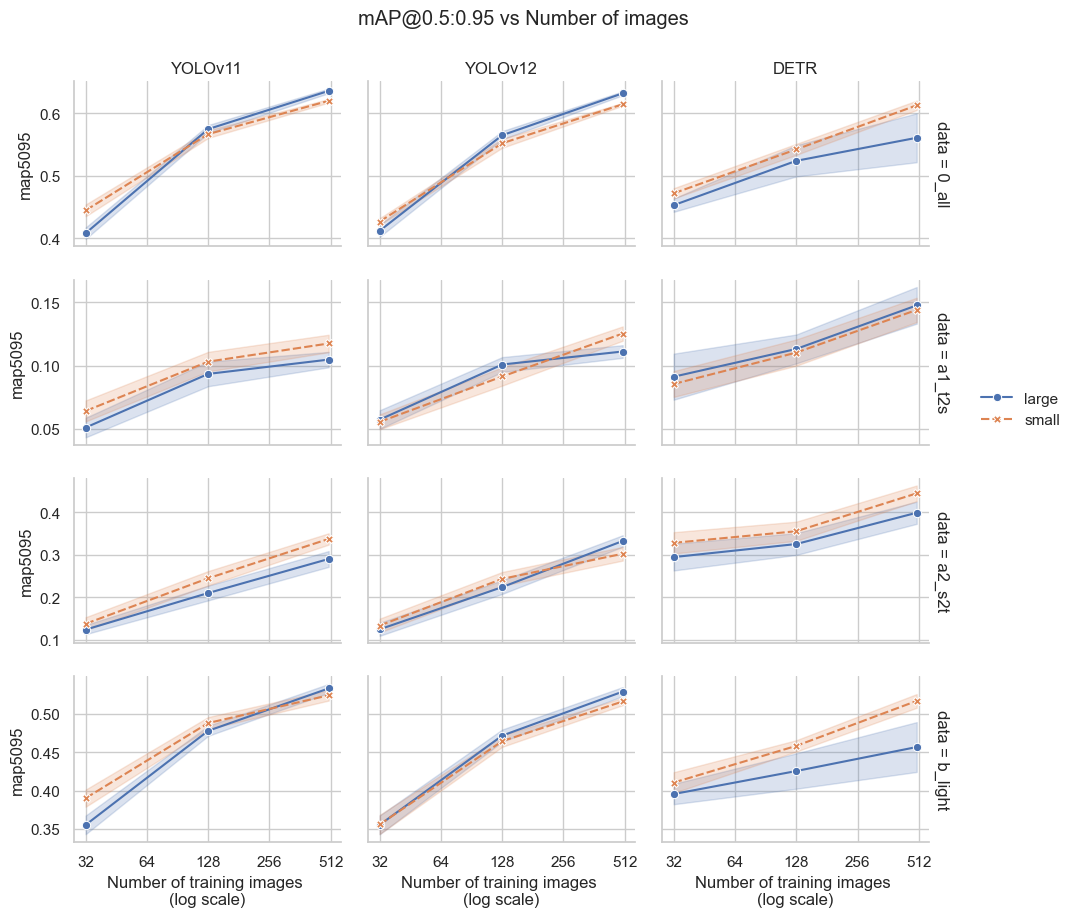

In [11]:
config_s1 = ["0_all", "a1_t2s", "a2_s2t", "b_light"]
sns.set(style="whitegrid")
g = sns.FacetGrid(df_s1, 
    col="family", col_order=["YOLOv11", "YOLOv12", "DETR"],
    row="data", row_order=config_s1, sharey="row",
    margin_titles=True)
g.map_dataframe(sns.lineplot, 
    x="n", y="map5095", hue="size", style="size",
    hue_order=["large", "small"],
    style_order=["large", "small"],
    err_style="band", errorbar=("se", 2),
    markers=True,
    )
g.set(
    xscale="log",
    xticks=[2**i for i in range(5, 10)],
    xticklabels=[2**i for i in range(5, 10)],
    xlabel="Number of training images \n(log scale)",)

g.add_legend(bbox_to_anchor=(1, 0.5), loc='lower right')
g.set_titles(col_template="{col_name}")
g.figure.set_size_inches(11, 9)
g.figure.subplots_adjust(top=0.9, hspace=0.2, wspace=0.1)
g.fig.suptitle("mAP@0.5:0.95 vs Number of images")
g.savefig(PATHS["DIR_SRC"]/"ms"/"r1"/"src"/"fig_s1_by_models.png", dpi=300)

In [46]:
import scipy.stats as stats
config_ext = ["e_IMU", "e_VT"]
ls_family = ["YOLOv11", "YOLOv12", "DETR"]
ls_n = [16, 64, 200]
for c in config_ext:
    for f in ls_family:
        for size in ["small", "large"]:
            for n in ls_n:
                df_sub = df_s2.query(f"data == '{c}' and family == '{f}' and n == {n} and size == '{size}'")
                df_pretrain = df_sub.query("pretrain == True")
                df_no_pretrain = df_sub.query("pretrain == False")
                # run t-test on map5095
                t_stat, p_val = stats.ttest_ind(df_pretrain["map5095"], df_no_pretrain["map5095"])
                print(f"Config: {c}, Family: {f}, n: {n}, size: {size}, t-stat: {t_stat:.2f}, p-val: {p_val:.2e}")

Config: e_IMU, Family: YOLOv11, n: 16, size: small, t-stat: -6.35, p-val: 5.57e-09
Config: e_IMU, Family: YOLOv11, n: 64, size: small, t-stat: 0.28, p-val: 7.79e-01
Config: e_IMU, Family: YOLOv11, n: 200, size: small, t-stat: -0.45, p-val: 6.59e-01
Config: e_IMU, Family: YOLOv11, n: 16, size: large, t-stat: -5.14, p-val: 8.51e-06
Config: e_IMU, Family: YOLOv11, n: 64, size: large, t-stat: -1.46, p-val: 1.53e-01
Config: e_IMU, Family: YOLOv11, n: 200, size: large, t-stat: 1.96, p-val: 5.70e-02
Config: e_IMU, Family: YOLOv12, n: 16, size: small, t-stat: -8.30, p-val: 2.86e-13
Config: e_IMU, Family: YOLOv12, n: 64, size: small, t-stat: -1.86, p-val: 7.17e-02
Config: e_IMU, Family: YOLOv12, n: 200, size: small, t-stat: -2.90, p-val: 6.28e-03
Config: e_IMU, Family: YOLOv12, n: 16, size: large, t-stat: -6.56, p-val: 4.15e-08
Config: e_IMU, Family: YOLOv12, n: 64, size: large, t-stat: -2.50, p-val: 1.63e-02
Config: e_IMU, Family: YOLOv12, n: 200, size: large, t-stat: 0.55, p-val: 5.87e-01
Con

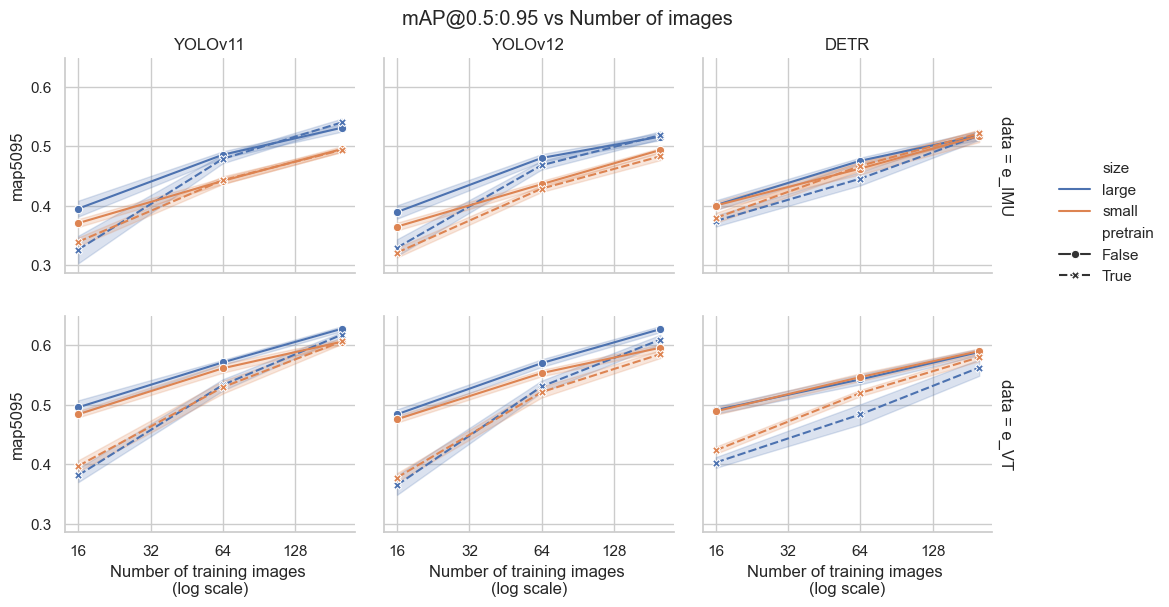

In [12]:
# facet by model
config_ext = ["e_IMU", "e_VT"]

g = sns.FacetGrid(df_s2, 
    row="data", col="family",
    col_order=["YOLOv11", "YOLOv12", "DETR"],
    margin_titles=True)
g.map_dataframe(sns.lineplot, 
    x="n", y="map5095", hue="size", style="pretrain",
    hue_order=["large", "small"],
     # style_order=["True", "False"],
    err_style="band", errorbar=("se", 2),
    markers=True,
    )
# x-axis: 32, 64, 128, 256, 500, in log scale
g.set(
    xscale="log",
    xticks=[2**i for i in range(4, 8)],
    xticklabels=[2**i for i in range(4, 8)],
    xlabel="Number of training images \n(log scale)",)
g.add_legend(bbox_to_anchor=(1, 0.5), loc='lower right')
g.set_titles(col_template="{col_name}")
g.figure.set_size_inches(12, 6)
g.figure.subplots_adjust(top=0.9, hspace=0.2, wspace=0.1)
g.fig.suptitle("mAP@0.5:0.95 vs Number of images")
g.savefig(PATHS["DIR_SRC"]/"ms"/"r1"/"src"/"fig_s2_overview.png", dpi=300)

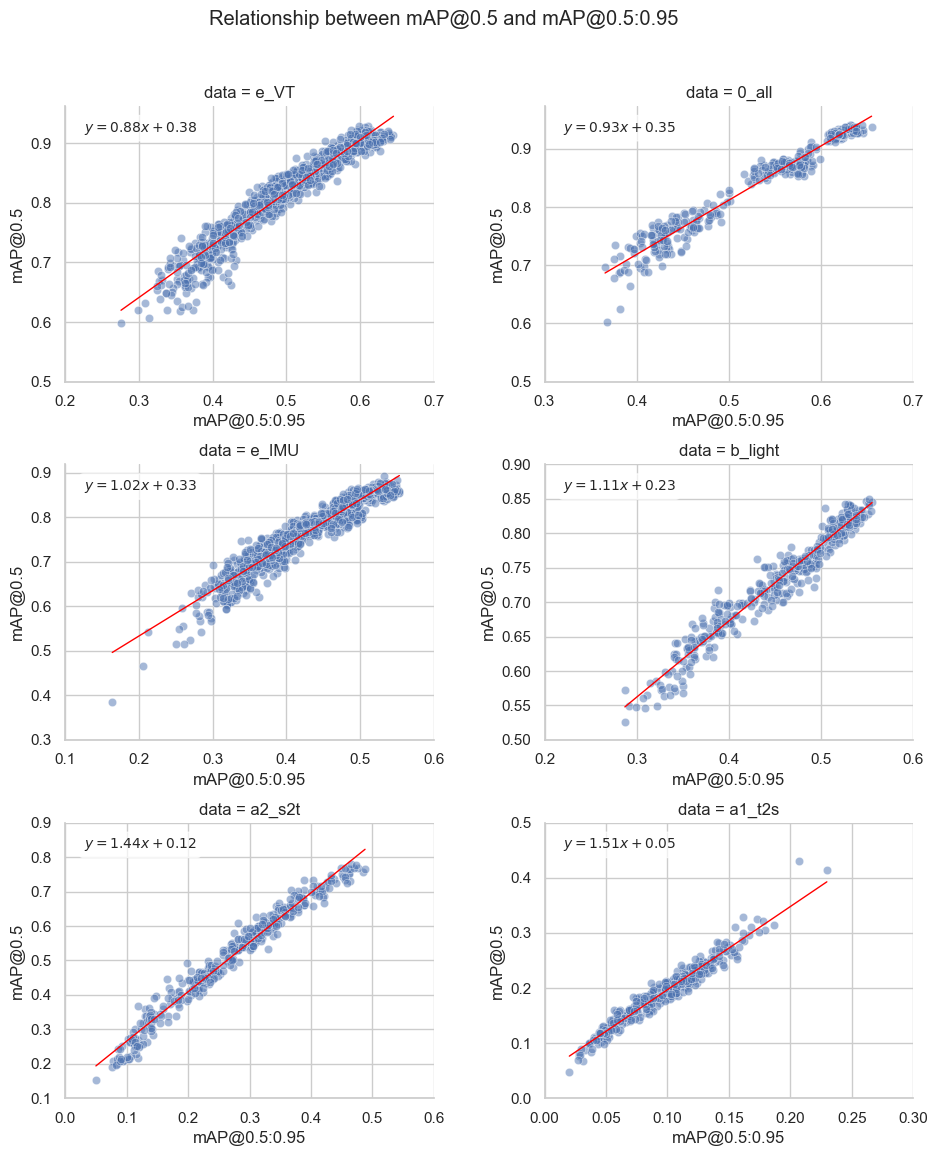

In [13]:
# merge data, family, size, map50, map5095
cols = ["data", "family", "size", "map50", "map5095"]
df_merge = pd.concat(
    [df_s1.loc[:, cols], 
     df_s2.loc[:, cols]],
)
# scatter plot
# hue: data
sns.set(style="whitegrid")
# wrap_col by data
g = sns.FacetGrid(df_merge, 
    sharey=False, sharex=False,
    col="data", col_wrap=2,
    col_order=["e_VT", "0_all",
               "e_IMU", "b_light", 
               "a2_s2t", "a1_t2s"],
    margin_titles=True
)
# Map the scatterplot first (with hue)
g.map_dataframe(
    sns.scatterplot,
    x="map5095", y="map50",
    alpha=0.5,
    zorder=1,
)

# For each subplot: fit a line, draw it behind dots, and annotate
for ax, (data_key, sub_data) in zip(g.axes.flat, g.facet_data()):
    # Fit line
    x = sub_data["map5095"]
    y = sub_data["map50"]
    if len(x) < 2:  # skip if not enough points
        continue
    slope, intercept = np.polyfit(x, y, deg=1)

    # Create line data for plotting
    x_vals = np.linspace(x.min(), x.max(), 100)
    y_vals = slope * x_vals + intercept

    # Plot the line behind the dots
    ax.plot(x_vals, y_vals, 
            lw=1,
            color="red", zorder=1)  # lower zorder puts line behind

    # Add equation text
    eqn = f"$y = {slope:.2f}x + {intercept:.2f}$"
    ax.text(
        0.05, 0.95, eqn,
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment="top",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7)
    )

    # Custom ticks at 0.1 intervals
    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()
    x_rg_min = np.max([0, np.floor(x_min * 10) / 10])
    x_rg_max = np.min([1, np.ceil(x_max * 10) / 10 + 0.1])
    y_rg_min = np.max([0, np.floor(y_min * 10) / 10])
    y_rg_max = np.min([1, np.ceil(y_max * 10) / 10 + 0.1])
    ax.set_xticks(np.arange(x_rg_min, x_rg_max, 0.1))
    ax.set_yticks(np.arange(y_rg_min, y_rg_max, 0.1))
    ax.grid(True)

# Set labels
g.set(
    xscale="linear",
    yscale="linear",
    xlabel="mAP@0.5:0.95",
    ylabel="mAP@0.5",
)
g.figure.set_size_inches(10, 12)
g.figure.subplots_adjust(top=0.9, hspace=0.3, wspace=0.3)
g.fig.suptitle("Relationship between mAP@0.5 and mAP@0.5:0.95")

g.savefig(PATHS["DIR_SRC"]/"ms"/"r1"/"src"/"fig_metrics.png", dpi=300)

In [15]:
df_time

,model,thread,median,filename,family,size,gpu,params
0,yolo12x,0,5.221078,study1/thread_0/0_all_yolo12x_128/iter_1/event...,YOLOv12,large,a100 (80GB),59.1
1,yolo12x,1,5.343491,study1/thread_1/0_all_yolo12x_128/iter_1/event...,YOLOv12,large,a100 (80GB),59.1
2,yolo12x,2,5.312509,study1/thread_2/0_all_yolo12x_128/iter_1/event...,YOLOv12,large,a100 (80GB),59.1
3,yolo12x,3,5.210836,study1/thread_3/0_all_yolo12x_128/iter_1/event...,YOLOv12,large,a100 (80GB),59.1
4,yolo12x,4,5.234777,study1/thread_4/0_all_yolo12x_128/iter_1/event...,YOLOv12,large,a100 (80GB),59.1
5,yolo12x,5,5.333816,study1/thread_5/0_all_yolo12x_128/iter_1/event...,YOLOv12,large,l40s (48GB),59.1
6,yolo12x,6,5.319082,study1/thread_6/0_all_yolo12x_128/iter_1/event...,YOLOv12,large,l40s (48GB),59.1
7,yolo12x,7,5.303691,study1/thread_7/0_all_yolo12x_128/iter_1/event...,YOLOv12,large,l40s (48GB),59.1
8,yolo12x,8,5.225213,study1/thread_8/0_all_yolo12x_128/iter_1/event...,YOLOv12,large,l40s (48GB),59.1
9,yolo12x,9,5.284211,study1/thread_9/0_all_yolo12x_128/iter_1/event...,YOLOv12,large,l40s (48GB),59.1


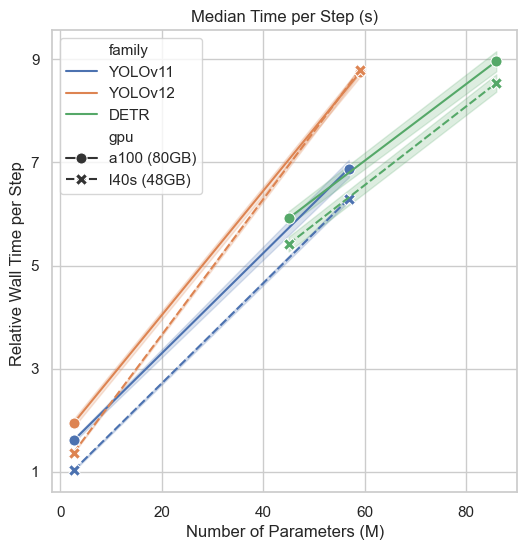

In [ ]:
min_mu = df_time["median"].min()
df_time["mu_std"] = df_time["median"] / min_mu

sns.set(style="whitegrid")
plt.figure(figsize=(6, 6))
sns.lineplot(data=df_time, x="params", y="mu_std", 
             hue="family", style="gpu",
             hue_order=["YOLOv11", "YOLOv12", "DETR"],
             err_style="band", errorbar=("se", 2),
             markers=True, markersize=8,

             )
# y tick
plt.yticks(np.arange(1, 10, 2))
plt.xticks(np.arange(0, 100, 20))
plt.title("Median Time per Step (s)")
plt.ylabel("Relative Wall Time per Step ")
plt.xlabel("Number of Parameters (M)")
# move legend to the right
# plt.legend(title="Family", loc="upper left", bbox_to_anchor=(1, 1))
plt.savefig(PATHS["DIR_SRC"]/"ms"/"r1"/"src"/"fig_time.png", dpi=300)

In [28]:
df_ram

,mem,n,model,family,size,params
0,25.60,32,yolo12x,YOLOv12,large,59.1
1,26.90,128,yolo12x,YOLOv12,large,59.1
2,28.30,500,yolo12x,YOLOv12,large,59.1
3,26.00,32,yolo12x,YOLOv12,large,59.1
4,26.90,128,yolo12x,YOLOv12,large,59.1
...,...,...,...,...,...,...
67,6.90,128,yolo11n,YOLOv11,small,2.6
68,7.07,500,yolo11n,YOLOv11,small,2.6
69,5.68,32,yolo11n,YOLOv11,small,2.6
70,6.94,128,yolo11n,YOLOv11,small,2.6


<Figure size 700x600 with 0 Axes>

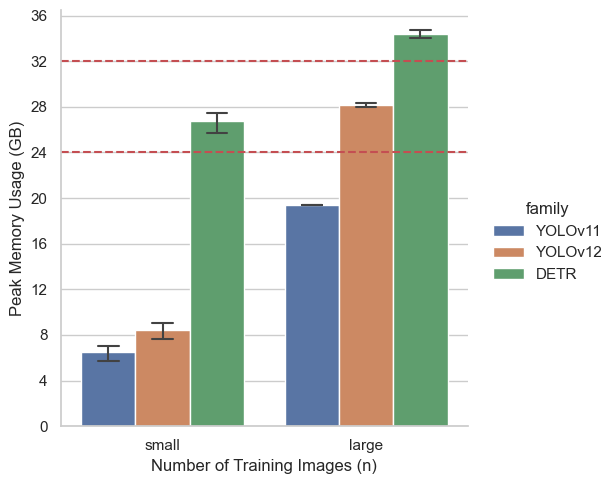

In [ ]:
sns.set(style="whitegrid")
plt.figure(figsize=(7, 6))

df_ram["size"] = df_ram["size"].astype("category")
df_ram["size"] = df_ram["size"].cat.reorder_categories(["small", "large"])
g = sns.catplot(
    data=df_ram.query("n == 500"), x="size", y="mem",     
    kind="bar",
    hue="family", 
    hue_order=["YOLOv11", "YOLOv12", "DETR"],
    capsize=.3, err_kws={"linewidth": 1.5},
            )
# draw red line on 24 and 32
g.map(plt.axhline, y=24, color="r", linestyle="--")
g.map(plt.axhline, y=32, color="r", linestyle="--")

g.set(
    yticks=[4*i for i in range(10)],
    yticklabels=[4*i for i in range(10)],
    ylabel="Peak Memory Usage (GB)",
    xlabel="Number of Training Images (n)",
)

plt.savefig(PATHS["DIR_SRC"]/"ms"/"r1"/"src"/"fig_ram.png", dpi=300)